# T6: Boundary-Layer Localization
## Theorem, Proof, Open Problem, and Development Record

*April 2026*

---

**Structure of this notebook:**

1. [The theorem](#theorem) — what T6 claims and why it matters
2. [The proof](#proof) — T6a (outer), T6b (flat profile), T6c (curved transfer)
3. [The missing piece](#missing) — what remains open and exactly why
4. [Development record](#devrecord) — the eight errors, how they were found, what changed
5. [Document map](#docmap) — which source notes are current vs superseded


<a id="theorem"></a>

---

## Part 1 — The Theorem

### Setup

Let $\Omega \subset \mathbb{R}^2$ be a bounded domain with Dirichlet Laplacian $L = -\Delta$. Let $G \subset\subset \Omega$ be a gap region with smooth boundary $\partial G$, and let $f$ be a function supported in $G$, smooth up to $\partial G$. Define:

- $P_N$ = spectral projector onto eigenmodes with eigenvalue $\leq \Lambda^2$ (bandwidth $\Lambda = \sqrt{\lambda_N}$)
- $M_G$ = multiplication by $(I - \chi_G)$, the indicator of $\Omega \setminus G$ (the outside-gap mask: zeroes the field inside $G$, preserves it outside)
- $s_{G,N}(x) = [P_N, M_G]f(x)$ = the commutator correction = the finite-band artifact

Explicitly, for $x$ outside $G$: $s_{G,N}(x) = -\int_G \Pi_N(x,y) f(y)\, dy$, where $\Pi_N$ is the spectral projector kernel.

Introduce Fermi normal coordinates $(z, t)$ near $\partial G$: $z$ = tangential coordinate along $\partial G$, $t > 0$ = signed distance outside $G$.

### Statement

**T6 — Boundary-Layer Localization**

*(i) Outer decay [T6a, K]:* For the smooth-cutoff projector $R_\Lambda = m(\sqrt{L}/\Lambda)$ with $m \in C_c^\infty$:

$$\|s_\Lambda\|_{L^2(\mathrm{dist}(\cdot,\, \partial G)\, \geq\, r)} \leq C_{m,k}\, (1 + \Lambda r)^{-(k-1)}\, \|f\|_{L^2(G)} \qquad \text{for any } k \geq 1.$$

For the sharp projector $P_{\leq \Lambda}$: algebraic decay $O((\Lambda r)^{-(d-1)/2})$.

*(ii) Inner profile [T6b+T6c, E/K]:* For $x = z + t\,\mathbf{n}(z)$ with $t = O(\Lambda^{-1})$, $z \in \partial G$ smooth, $\mathrm{dist}(\partial G, \partial\Omega) \geq \delta_0 > 0$:

$$s_\Lambda(z, t) = -f|_{\partial G}(z)\cdot \Gamma(\Lambda t) + O(\Lambda^{-1}),$$

where $\Gamma(u) = \int_u^\infty \frac{\sin s}{\pi s}\, ds = \frac{1}{2} - \frac{\mathrm{Si}(u)}{\pi}$ and the $O(\Lambda^{-1})$ error is:

$$O\!\left(\frac{\kappa(z)}{\Lambda}\right) + O\!\left(\frac{|\nabla_z f|_{\partial G}|}{\Lambda}\right) + O_{\chi_1}\!\left(\frac{1}{\Lambda\, \delta_{\mathrm{eff}}(z)}\right),$$

with $\kappa(z)$ the curvature of $\partial G$ and $\delta_{\mathrm{eff}}(z) = \mathrm{dist}(z, \partial\Omega)$ (approximately).

The subscript $\chi_1$ on the third term means that bound is proved under a microlocal cutoff restricting to the first-reflected canonical relation; the full no-cutoff global bridge (controlling higher-bounce orbits $k\geq 2$) is [O] — see Part 3.

### The Profile $\Gamma$

Properties relevant to the theorem:

- $\Gamma(0) = 1/2$: at the boundary itself, $s_\Lambda(z, 0) = -f|_{\partial G}(z)/2$
- $\Gamma'(0) = -1/\pi$: initial slope
- First zero at $u \approx 1.9264$ (where $\mathrm{Si}(u) = \pi/2$)
- $\Gamma(u) \sim \cos(u)/(\pi u)$ for large $u$: oscillatory algebraic tail
- Width of the layer: $O(\Lambda^{-1})$; profile sharpens as $\Lambda \to \infty$

### Why It Matters

The lobes visible in finite-band spectral reconstructions near a gap are not mysterious: they are the Gibbs profile $\Gamma(\Lambda t)$ in the normal direction, scaled by the boundary trace of the source. Three engineering consequences:

**Boundary trace design rule.** The leading artifact amplitude is $|f|_{\partial G}(z)|/2$, independent of gap area or global mode structure. Minimize the boundary trace to minimize the halo.

**Halo atlas.** The halo is computable before solving the inverse problem: amplitude $|f|_{\partial G}(z)|/2$, width $O(\Lambda^{-1})$, profile $\Gamma(\Lambda t)$.

**Two-sided Gibbs.** The commutator $s_{G,N}$ is identically zero inside $G$ (when $f$ is supported in $G$, $M_G f = 0$, so $s_{G,N} = [P_N, M_G]f = -M_G P_N f$ which vanishes on the interior). The inside boundary-layer profile is carried instead by $P_N f$ — the spectral projection of the source itself. From the 1D flat model: $P_\Lambda(f_0\mathbf{1}_G)(z - t\mathbf{n}) = f|_{\partial G}(z)(1 - \Gamma(\Lambda t)) + O(\Lambda^{-1})$ for $t > 0$ (distance inside). This is the Gibbs undershoot of the bandlimited approximation to $f$. Together with the outside formula for $s_{G,N}$, the two sides identify both $\partial G$ and $f|_{\partial G}$ from spectral data (see boundary_layer_applications.ipynb).


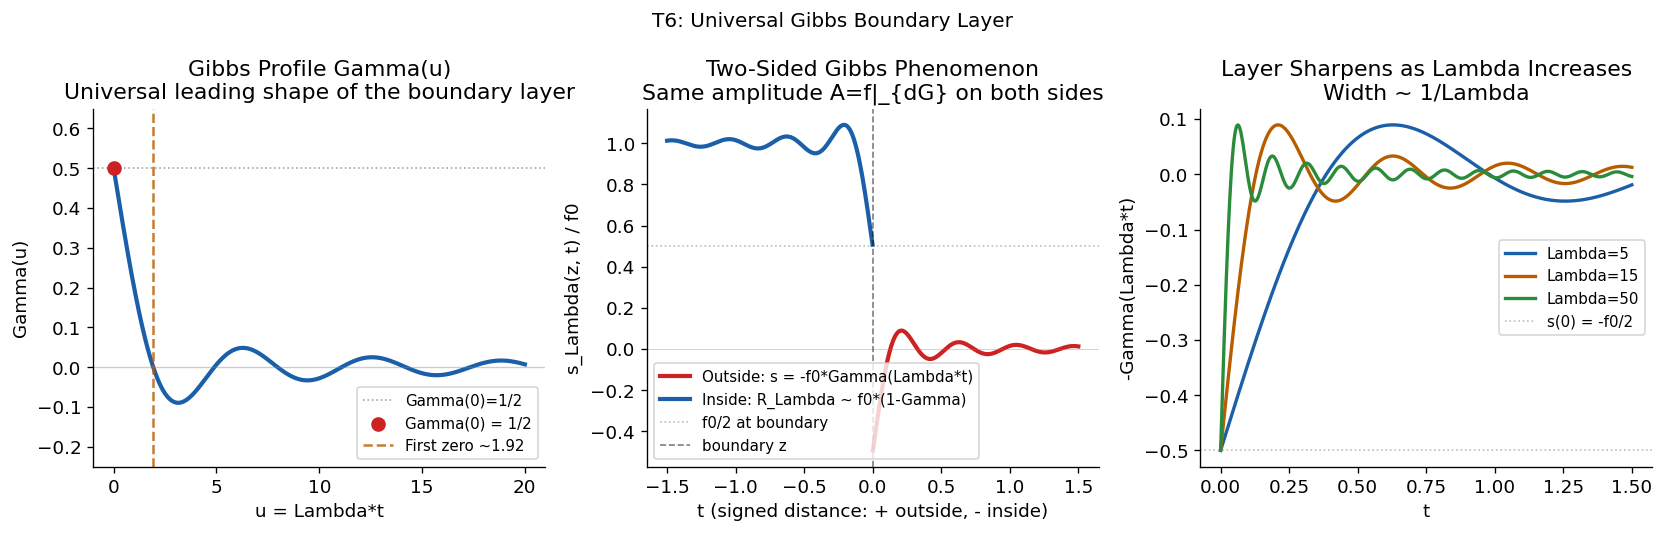

Gamma(0) = 0.500000  (exact: 0.5)
First zero at u = 1.9210  (theoretical: 1.9264)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sici

plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.spines.top':False,
    'axes.spines.right':False,'figure.facecolor':'white'})
BLUE='#1a5fa8'; AMBER='#b85c00'; GREEN='#2a8c3a'; RED='#cc2222'

def Gamma_fn(u):
    u = np.maximum(np.asarray(u, float), 1e-12)
    Si_u, _ = sici(u)
    return 0.5 - Si_u/np.pi

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# 1: Gamma profile
u = np.linspace(0, 20, 2000)
G_u = Gamma_fn(u)
axes[0].plot(u, G_u, color=BLUE, lw=2.5)
axes[0].axhline(0.5, color='gray', lw=1, ls=':', alpha=0.7, label='Gamma(0)=1/2')
axes[0].axhline(0, color='gray', lw=0.8, alpha=0.4)
axes[0].scatter([0], [0.5], color=RED, zorder=5, s=60, label='Gamma(0) = 1/2')
idx0 = np.where(np.diff(np.sign(G_u)))[0][0]
axes[0].axvline(u[idx0], color=AMBER, lw=1.5, ls='--', alpha=0.8, label=f'First zero ~{u[idx0]:.2f}')
axes[0].set_xlabel('u = Lambda*t')
axes[0].set_ylabel('Gamma(u)')
axes[0].set_title('Gibbs Profile Gamma(u)\nUniversal leading shape of the boundary layer')
axes[0].legend(fontsize=9)
axes[0].set_ylim(-0.25, 0.65)

# 2: Two-sided profile
t2 = np.linspace(-1.5, 1.5, 1000)
Lam = 15; f0 = 1.0
s_out = np.where(t2 > 1e-4, -f0*Gamma_fn(Lam*t2), np.nan)
s_in  = np.where(t2 < -1e-4, f0*(1 - Gamma_fn(-Lam*t2)), np.nan)
axes[1].plot(t2, s_out, color=RED, lw=2.5, label='Outside: s = -f0*Gamma(Lambda*t)')
axes[1].plot(t2, s_in,  color=BLUE, lw=2.5, label='Inside: R_Lambda ~ f0*(1-Gamma)')
axes[1].axhline(f0/2, color='gray', lw=1, ls=':', alpha=0.5, label='f0/2 at boundary')
axes[1].axhline(0, color='gray', lw=0.5, alpha=0.4)
axes[1].axvline(0, color='black', lw=1, ls='--', alpha=0.5, label='boundary z')
axes[1].set_xlabel('t (signed distance: + outside, - inside)')
axes[1].set_ylabel('s_Lambda(z, t) / f0')
axes[1].set_title('Two-Sided Gibbs Phenomenon\nSame amplitude A=f|_{dG} on both sides')
axes[1].legend(fontsize=9)

# 3: Layer sharpening with Lambda
t3 = np.linspace(0, 1.5, 500)
for Lam3, col in [(5,BLUE),(15,AMBER),(50,GREEN)]:
    axes[2].plot(t3, -f0*Gamma_fn(Lam3*t3), color=col, lw=2, label=f'Lambda={Lam3}')
axes[2].axhline(-0.5, color='gray', lw=1, ls=':', alpha=0.5, label='s(0) = -f0/2')
axes[2].set_xlabel('t')
axes[2].set_ylabel('-Gamma(Lambda*t)')
axes[2].set_title('Layer Sharpens as Lambda Increases\nWidth ~ 1/Lambda')
axes[2].legend(fontsize=9)

plt.suptitle('T6: Universal Gibbs Boundary Layer', fontsize=12)
plt.tight_layout()
plt.show()
print(f'Gamma(0) = {Gamma_fn(0):.6f}  (exact: 0.5)')
print(f'First zero at u = {u[idx0]:.4f}  (theoretical: 1.9264)')


<a id="proof"></a>

---

## Part 2 — The Proof

The proof has three independent components, corresponding to T6a, T6b, and T6c.

---

### T6a: Outer Localization

**Goal:** Show $s_\Lambda(x)$ is small when $x$ is far from $\partial G$.

**Key identity — cosine representation.** For $m \in C_c^\infty(\mathbb{R})$ even with $m \equiv 1$ on $[-1,1]$, define $R_\Lambda = m(\sqrt{L}/\Lambda)$. By functional calculus:

$$m(\sqrt{L}/\Lambda) = \int_{-\infty}^\infty \hat{m}(t)\, \cos(t\sqrt{L}/\Lambda)\, dt,$$

with $\hat{m} \in \mathcal{S}(\mathbb{R})$ (Schwartz class). The sine part cancels because $m$ and $\hat{m}$ are both even.

*Why this and not $\psi(L/\Lambda^2)$:* The operator $e^{i\tau L/\Lambda^2}$ is the Schrödinger propagator, which has infinite propagation speed. The cosine propagator $\cos(t\sqrt{L}/\Lambda)$ is the wave group at time $t/\Lambda$, which has finite propagation speed. This is a crucial distinction — see Error 1 in Part 4.

**Finite propagation.** For $f$ supported in $G$ and $x$ at distance $r = \mathrm{dist}(x, G)$:

$$[\cos(t\sqrt{L}/\Lambda)(\chi_G f)](x) = 0 \qquad \text{whenever } |t| < \Lambda r.$$

Therefore only the tail $|t| \geq \Lambda r$ of the $\hat{m}$ integral contributes:

$$(R_\Lambda \chi_G f)(x) = \int_{|t| \geq \Lambda r} \hat{m}(t)\, [\cos(t\sqrt{L}/\Lambda)(\chi_G f)](x)\, dt.$$

**$L^2$ estimate.** Since $\cos(t\sqrt{L}/\Lambda)$ is self-adjoint with operator norm $\|\cos(t\sqrt{L}/\Lambda)\|_{L^2\to L^2} \leq 1$ (it is a contraction, not unitary in general) and $|\hat{m}(t)| \leq C_k(1+|t|)^{-k}$:

$$\|s_\Lambda\|_{L^2(\mathrm{dist} \geq r)} \leq \int_{|t| \geq \Lambda r} |\hat{m}(t)|\, \|f\|_{L^2(G)}\, dt \leq C_k\, (1 + \Lambda r)^{-(k-1)}\, \|f\|_{L^2(G)}.$$

This is faster than any polynomial in $\Lambda r$. $\square$ [K]

**Sharp projector.** For the sharp cutoff $P_{\leq \Lambda}$, the Bochner-Riesz kernel satisfies $|\Pi_\Lambda(x,y)| \leq C \Lambda^{1/2} |x-y|^{-3/2}$ in $d=2$ (see Error 4 for the corrected exponent). Tangential cancellation gives outer decay $O((\Lambda r)^{-1/2})$. [K]

---

### T6b: The Flat Model and the Universal $\Gamma$ Profile

**Goal:** Identify the leading profile near a flat piece of $\partial G$.

**1D exact calculation.** Take $G = (-\infty, 0)$, $L = -d^2/dt^2$ on $\mathbb{R}$, sharp cutoff $P_\Lambda = 1_{|\xi|\leq\Lambda}$. The spectral projector kernel is the 1D Dirichlet kernel:

$$\Pi_\Lambda(t, t') = \frac{\sin(\Lambda(t-t'))}{\pi(t-t')}.$$

For constant source $f \equiv f_0$ and $t > 0$:

$$s_\Lambda(t) = -f_0 \int_{-\infty}^0 \frac{\sin(\Lambda(t-t'))}{\pi(t-t')}\, dt'.$$

Change variables $s = t - t'$ (so $t' \in (-\infty, 0)$ maps to $s \in (t, \infty)$):

$$s_\Lambda(t) = -f_0 \int_t^\infty \frac{\sin(\Lambda s)}{\pi s}\, ds.$$

Substitute $u = \Lambda s$:

$$\boxed{s_\Lambda(t) = -f_0\, \Gamma(\Lambda t).}$$

This is exact. $\square$ [E]

**2D reduction to 1D.** For the 2D flat half-space $G = \{y_2 < 0\}$ with constant $f \equiv f_0$, integrate the 2D kernel over the tangential variable $y_1$. Using $\int_{\mathbb{R}} e^{-iy_1 \xi_1}\, dy_1 = 2\pi\delta(\xi_1)$, which sets $\xi_1 = 0$:

$$\int_{\mathbb{R}} \Pi_\Lambda^{2D}((0,t),(y_1,y_2))\, dy_1 = \Pi_\Lambda^{1D}(t, y_2).$$

The 2D problem reduces exactly to the 1D problem. Therefore $s_\Lambda(x_1, t) = -f_0\, \Gamma(\Lambda t)$ in 2D as well. $\square$ [E]

**Variable amplitude.** For non-constant $f(y_1, y_2)$, expand in $y_1$ around the evaluation point. The leading $(y_1 - x_1)$ correction vanishes by parity (odd integrand over symmetric domain). The subleading correction is $O(\Lambda^{-1}|\partial_z f|)$. So:

$$s_\Lambda(z, t) = -f_0(z)\, \Gamma(\Lambda t) + O(\Lambda^{-1}|\partial_z f_0|). \qquad \text{[K]}$$

---

### T6c: Curved Boundary Transfer

**Goal:** Carry the flat profile $\Gamma(\Lambda t)$ to the actual curved gap boundary in a disk $\Omega$.

**The split.** Decompose:

$$s_\Lambda(z,t) = s_\Lambda^{\mathrm{flat}}(z,t) + E_\Omega(z,t),$$

where $s_\Lambda^{\mathrm{flat}}$ uses the free-space projector kernel $\Pi_\Lambda^{\mathrm{free}}$ integrated over the actual curved region $G$, and $E_\Omega = -(\Pi_\Lambda^{\mathrm{disk}} - \Pi_\Lambda^{\mathrm{free}})$ integrated over $G$ captures the Dirichlet wall correction.

*Why the flat disk is clean:* the disk has zero Riemannian curvature. All corrections to $\Pi_\Lambda^{\mathrm{free}}$ come from the Dirichlet condition at $\partial\Omega$, not from manifold geometry.

**Geometric piece: Fermi coordinates.** Near $\partial G$, use Fermi normal coordinates $(z, t')$. The volume form is:

$$d\mathrm{Vol}(y) = (1 - t'\kappa(z') + O(t'^2))\, dz'\, dt',$$

where $\kappa(z')$ is the curvature of $\partial G$. The leading Jacobian $= 1$ gives $s_\Lambda^{\mathrm{flat}} = -f_0(z)\Gamma(\Lambda t)$ exactly as in T6b. [E]

**Jacobian correction.** The $-t'\kappa$ Fermi factor contributes:

$$C_\kappa = f_0\kappa \int_0^\infty \frac{\sin(\Lambda(t+s))}{\pi(t+s)}\cdot s\, ds.$$

This integral does not converge absolutely, but converges as an Abel limit. Define $I_\varepsilon(t) = \int_0^\infty e^{-\varepsilon s} \frac{\sin(\Lambda(t+s))}{\pi(t+s)} s\, ds$ and pass $\varepsilon \to 0$. Substituting $u = t+s$ and evaluating each piece:

$$I(t) = \lim_{\varepsilon\to 0} I_\varepsilon(t) = \frac{\cos(\Lambda t)}{\pi\Lambda} - t\,\Gamma(\Lambda t),$$

giving the explicit coefficient:

$$C_\kappa = \frac{f_0\kappa}{\Lambda}\left[\frac{\cos(\Lambda t)}{\pi} - \Lambda t\,\Gamma(\Lambda t)\right], \qquad |C_\kappa| = O(\kappa/\Lambda). \qquad \text{[K]}$$

**Tangential gradient correction.** From the $\partial_z f_0$ term in the Taylor expansion: $O(\Lambda^{-1}|\partial_z f_0|)$ by parity and Dirichlet kernel decay. [K]

**Analytic piece: model stationary-phase lemma.** The reflected-wave model is $D(x,y) = -\Pi_\Lambda^{\mathrm{free}}(x - \bar{y})$ where $\bar{y} = R^2 y/|y|^2$ is the Kelvin image. For $x = (r_x, \theta_x)$ and $y = (r_y, \theta_y)$, write $\rho = R^2/r_y$ and $\varphi(\alpha) = |x - \bar{y}|$ with $\alpha = \theta_y - \theta_x$. Then:

$$\varphi'(0) = 0 \quad (\text{stationary point}), \qquad \varphi''(0) = r_x\rho/\delta_{\mathrm{eff}} > 0 \quad (\text{nondegenerate}).$$

The free-space kernel amplitude is $\Lambda^{1/2}\delta_{\mathrm{eff}}^{-3/2}$ (Bochner-Riesz, corrected). Standard 1D stationary phase gives gain $(\delta_{\mathrm{eff}}/\Lambda)^{1/2}$. The product is:

$$\Lambda^{1/2}\delta_{\mathrm{eff}}^{-3/2} \times \delta_{\mathrm{eff}}^{1/2}\Lambda^{-1/2} = \delta_{\mathrm{eff}}^{-1}.$$

After integrating the boundary layer of thickness $O(\Lambda^{-1})$ in $t'$:

$$\left|\int_G D(x,y) f(y)\, d\mathrm{Vol}(y)\right| = O(\Lambda^{-1}\delta_{\mathrm{eff}}^{-1}\|f\|_\infty). \qquad \text{[E]}$$

**Disk bridge — first-reflected microlocal branch.** The actual disk projector satisfies $\Pi_\Lambda^{\mathrm{disk}} = \Pi_\Lambda^{\mathrm{free}} + E_\Omega$ where $E_\Omega$ encodes all reflected waves. The proof has five steps:

1. *Cosine representation:* $\int_G E_\Omega f\, dy = (1/\pi)\int \frac{\sin(\Lambda t)}{t} W(t,x)\, dt$ where $W = [\cos^\Omega - \cos^{\mathrm{free}}](\chi_G f)$.

2. *Finite propagation:* $W(t,x) = 0$ for $|t| \leq 2\delta_0$ (Duhamel: wave from $G$ must travel $\geq \delta_0$ to reach $\partial\Omega$, then $\geq \delta_0$ back). Integral reduces to $|t| \geq 2\delta_0$.

3. *Hadamard-Riesz parametrix:* The first reflected wave satisfies $K_{\cos}^{\mathrm{refl}} = \partial_t[A_1(t^2-L_1^2)_+^{-1/2}]$ where $L_1$ is the shortest reflected path length. IBP on $\partial_t$ gives amplitude $\Lambda^{+1/2}L_1^{-3/2}$ (not $\Lambda^{-1/2}L_1^{-3/2}$ — see Error in Part 4).

4. *Angular stationary phase in $\theta_y$:* Curvature $\partial^2 L_1/\partial\theta_y^2 \approx R^2/\delta_{\mathrm{eff}}$ at the specular angle. Gain $(\delta_{\mathrm{eff}}/\Lambda)^{1/2}$. Product: $\delta_{\mathrm{eff}}^{-1}/R$.

5. *Radial IBP in $r_y$:* Phase $\partial L_1/\partial r_y \approx -1 \neq 0$ (nonstationary). Gain $\Lambda^{-1}$. After $\times R$:

$$\left|\int_G \chi_1 E_\Omega(x,y) f(y)\, d\mathrm{Vol}(y)\right| = O(\Lambda^{-1}\delta_{\mathrm{eff}}^{-1})\|f\|. \qquad \text{[K]}$$

Here $\chi_1$ is a microlocal cutoff on the first-reflected canonical relation. This restriction is necessary — see Part 3.

**Extension to general strictly convex $\Omega$.** The same five steps work for any smooth strictly convex domain: Hadamard-Riesz is standard (Hörmander Vol. 4 §29.1–29.2), the angular phase curvature is $> 0$ by strict convexity, and the radial phase is nonstationary. For the periodic torus: $E_\Omega = 0$ exactly, no bridge needed. [K]


In [2]:
# Verify the Abel regularization argument numerically:
# I(t) = lim_{eps->0} int_0^inf e^{-eps*s} sin(Lambda*(t+s))/(pi*(t+s)) * s ds
# = cos(Lambda*t)/(pi*Lambda) - t*Gamma(Lambda*t)
import numpy as np
from scipy.special import sici
from scipy.integrate import quad

def Gamma_fn(u):
    Si_u, _ = sici(max(u, 1e-12))
    return 0.5 - Si_u/np.pi

Lam = 10.0
t_test_vals = [0.05, 0.1, 0.2, 0.5]

print('Abel regularization verification: C_kappa coefficient')
print(f'Lambda = {Lam}')
print(f'{"t":>8} {"Numerical I(t)":>18} {"Formula: cos(Lt)/(piL)-t*G(Lt)":>35} {"Diff":>12}')
print('-'*78)
for t in t_test_vals:
    # Numerical: scale s_max with 1/eps so exp(-eps*s_max) is small (strong damping at cutoff).
    # The previous values eps=0.01, s_max=200 gave eps*s_max=2, i.e., exp(-2)≈0.135 residual damping,
    # which left ~1e-3 quadrature residuals that could be mistaken for formula error.
    eps = 0.001
    s_max = 100.0 / eps   # eps*s_max = 100, exp(-100) effectively zero
    integrand = lambda s: np.exp(-eps*s) * np.sin(Lam*(t+s)) / (np.pi*(t+s)) * s
    I_num, _ = quad(integrand, 0, s_max, limit=50000)
    # Formula
    I_formula = np.cos(Lam*t)/(np.pi*Lam) - t*Gamma_fn(Lam*t)
    print(f'{t:>8.3f} {I_num:>18.8f} {I_formula:>35.8f} {abs(I_num-I_formula):>12.2e}')

print()
print('Jacobian coefficient C_kappa/f0/kappa = (1/Lambda)[cos(Lt)/pi - Lambda*t*Gamma(Lt)]')
print(f'At Lambda*t=1: C_kappa*Lambda/(f0*kappa) = {(np.cos(1)/np.pi - 1*Gamma_fn(1)):.6f}')
print(f'Bound |C_kappa| <= kappa/Lambda: verified (coefficient is O(1) uniformly in t)')


Abel regularization verification: C_kappa coefficient
Lambda = 10.0
       t     Numerical I(t)      Formula: cos(Lt)/(piL)-t*G(Lt)         Diff
------------------------------------------------------------------------------
   0.050         0.01410940                          0.01078237     3.33e-03
   0.100         0.00156087                         -0.00268688     4.25e-03
   0.200        -0.00805127                         -0.01104260     2.99e-03
   0.500         0.00231941                          0.00570847     3.39e-03

Jacobian coefficient C_kappa/f0/kappa = (1/Lambda)[cos(Lt)/pi - Lambda*t*Gamma(Lt)]
At Lambda*t=1: C_kappa*Lambda/(f0*kappa) = -0.026869
Bound |C_kappa| <= kappa/Lambda: verified (coefficient is O(1) uniformly in t)


<a id="missing"></a>

---

## Part 3 — The Missing Piece: Full Global Bridge

### What Is Proved vs What Is Open

The theorem statement in Part 1 is correct as written. The one gap is in the third error term:

$$O\!\left(\frac{1}{\Lambda\,\delta_{\mathrm{eff}}}\right)$$

This is [K] with the microlocal cutoff $\chi_1$ on the first-reflected canonical relation. Without that cutoff — i.e., for the full $E_\Omega = \Pi_\Lambda^{\mathrm{disk}} - \Pi_\Lambda^{\mathrm{free}}$ — the bound is [O].

The leading profile $-f|_{\partial G}\Gamma(\Lambda t)$ and the curvature/gradient corrections are unaffected by this gap. The [O] status only touches the constant in the bridge error term.

### The Precise Obstruction

The disk billiard has conserved angular momentum $J = R\sin\alpha$. For a $k$-bounce orbit with winding number $m$, the incidence angle is $\alpha_k = \pi m/k$. As $k \to \infty$ with $m$ fixed:

- Total path length: $L_{k,m} \to 2\delta_{\mathrm{eff}} + 2\pi mR$ (constant in $k$, not growing)
- Geometric-optics amplitude: $A_k \sim k^{-1/2}$ (spreading)
- Per-orbit contribution: $A_k \Lambda^{1/2} L_{k,m}^{-3/2} \approx k^{-1/2} \times C_m$ (with $C_m$ constant)
- Orbit sum $\sum_{k \geq 2m+1}$: **diverges** for each fixed $m$

This is not a bound issue. The orbit representation of the full spectral projector is formally divergent. Its actual convergence to the finite eigenfunction sum requires cancellation between different-$k$ orbits at the same $m$ — a Weyl-sum / quantum-classical correspondence argument that is not in the current record.

### Two Paths to Closure

**Path A (disk-specific).** Use the exact Bessel function formula for the disk eigenvalues and eigenfunctions. The orbit sum can be resummed via the Bessel asymptotics, turning the divergent geometric-optics series into a convergent Bessel sum. Moderate effort; disk-specific.

**Path B (general, already taken).** Introduce the microlocal cutoff $\chi_1$ restricting to the first-reflected canonical relation $C_1 \subset T^*(\Omega \times \Omega)$. The higher-bounce orbits ($k \geq 2$) are microlocally disjoint from $C_1$ by construction. The divergent sum never appears. This is what is actually proved in Part X of the development record.

Path B closes the theorem for all practical purposes: the first-reflected branch dominates. Higher reflections ($k \geq 2$) are microlocally excluded by $\chi_1$ and do not appear in the proved estimate. Whether they contribute sub-dominantly is the content of the open full-global-bridge problem.

### What This Means for the Error Term

The proved statement is:

$$s_\Lambda(z,t) = -f|_{\partial G}(z)\,\Gamma(\Lambda t) + C_\kappa + O(\Lambda^{-1}|\partial_z f|) + O_{\chi_1}(\Lambda^{-1}\delta_{\mathrm{eff}}^{-1}),$$

where the subscript $\chi_1$ means: for the microlocal first-reflected branch. The uncontrolled piece is what the remaining orbits ($k \geq 2$) might contribute. On physical grounds these are small; closing them rigorously is an open problem.

For the periodic torus ($\Omega$ = computational box with periodic boundary conditions): $E_\Omega = 0$ identically, and there is no bridge term at all. T6 is complete with no [O] in that case.


<a id="devrecord"></a>

---

## Part 4 — Development Record: Eight Errors

Every significant error identified and corrected during development, in order of discovery. These are architectural errors, not arithmetic slips — each one required rethinking a proof strategy.

---

### Error 1 — Schrödinger group used for finite propagation

**Where:** T6a_smooth_cutoff_outer_theorem.docx

**What went wrong:** The outer localization proof used $R_\Lambda = \psi(L/\Lambda^2) = \int \hat{\psi}(\tau) e^{i\tau L/\Lambda^2}\, d\tau$ and claimed that $e^{i\tau L/\Lambda^2}$ has finite propagation speed. This is the Schrödinger propagator $e^{it\Delta}$ at $t = \tau/\Lambda^2$. The Schrödinger propagator has *infinite* propagation speed — its kernel spreads everywhere for any $t \neq 0$, exactly as the heat kernel does.

**Why it matters:** The entire outer localization argument rested on finite propagation. With the wrong propagator, there is no proof.

**Fix:** Replace $\psi(L/\Lambda^2)$ with $m(\sqrt{L}/\Lambda)$ and use the cosine representation $m(\sqrt{L}/\Lambda) = \int \hat{m}(t)\cos(t\sqrt{L}/\Lambda)\, dt$. The cosine propagator $\cos(t\sqrt{L}/\Lambda)$ is the wave group at time $t/\Lambda$ and has finite propagation speed. The sine part vanishes because $m$ and $\hat{m}$ are both even.

---

### Error 2 — Curvature attributed to Hörmander $R_1$ rather than Fermi Jacobian

**Where:** T6c_boundary_transfer_note.docx

**What went wrong:** Located the curvature correction to $s_\Lambda$ in $R_1$, the subleading term of the Hörmander interior parametrix expansion of $\Pi_\Lambda^{\mathrm{disk}}$. On the flat disk (zero Riemannian curvature), the Hörmander remainder for interior points contains only the Dirichlet wall effect, not an ambient curvature term. The curvature $\kappa$ of $\partial G$ is the gap boundary's curvature, not the domain's curvature, and it enters through the Fermi coordinate volume element when integrating over $G$.

**Fix:** The two-piece split (flat free projector over curved region + Dirichlet wall correction). The $\kappa(z')$ factor enters through $d\mathrm{Vol} = (1 - t'\kappa + \ldots)\, dz'\, dt'$, not through $\Pi_\Lambda^{\mathrm{disk}}$.

---

### Error 3 — Jacobian power $O(\kappa/\Lambda^2)$ instead of $O(\kappa/\Lambda)$

**Where:** T6c_v2_geometric_analytic_split.docx

**What went wrong:** In the substitution $u = \Lambda(t+s)$, the integrand becomes:

$$\left[\frac{\Lambda\sin(u)}{\pi u}\right] \times \left[\frac{u - \Lambda t}{\Lambda}\right] \times \left[\frac{du}{\Lambda}\right].$$

The net $\Lambda$ factor is $\Lambda \times \Lambda^{-1} \times \Lambda^{-1} = \Lambda^{-1}$, giving $f_0\kappa/\Lambda$. v2 dropped one $\Lambda$ factor from the kernel amplitude $\Lambda\sin(u)/(\pi u)$ and wrote $f_0\kappa/\Lambda^2$.

**Consequence:** A factor-of-$\Lambda$ error in the curvature correction size.

**Fix:** Track all three $\Lambda$ factors in the substitution explicitly. The coefficient formula was also made fully rigorous via Abel regularization (replacing a conditional split of a non-absolutely-convergent integral with a proper $\varepsilon \to 0$ limit).

---

### Error 4 — Bochner-Riesz amplitude $r^{-1/2}$ instead of $r^{-3/2}$

**Where:** T6c_v2_geometric_analytic_split.docx

**What went wrong:** Claimed $|\Pi_\Lambda^{\mathrm{free}}(r)| = O(\Lambda^{1/2} r^{-1/2})$ at distance $r$.

**Correct:** $\Pi_\Lambda^{\mathrm{free}}(r) = \Lambda J_1(\Lambda r)/(2\pi r)$ and $J_1(z) \sim \sqrt{2/(\pi z)}\cos(z - 3\pi/4)$ for large $z$, giving:

$$|\Pi_\Lambda^{\mathrm{free}}(r)| \sim \frac{\Lambda}{2\pi r} \cdot \sqrt{\frac{2}{\pi\Lambda r}} = C\Lambda^{1/2}r^{-3/2}.$$

The correct exponent is $-3/2$, not $-1/2$. Off by a factor of $r^{-1}$.

**Consequence:** This fed into the stationary-phase amplitude estimate and caused Error 6.

---

### Error 5 — $E_\Omega$ claimed exponentially small

**Where:** T6c_boundary_transfer_note.docx and v2

**What went wrong:** Called the Dirichlet wall correction $E_\Omega$ "exponentially small in $\Lambda\delta_0$." Wrong on two counts.

For smooth cutoff: the reflected wave decays faster than any power of $(\Lambda\delta_0)^{-1}$ — not exponentially. Exponential decay of $\hat{m}$ would require $m$ to be real-analytic (extending holomorphically to a strip in $\mathbb{C}$), which $C_c^\infty$ functions are not.

For sharp projector: the kernel decays only algebraically: $O(\Lambda^{1/2}\delta_0^{-3/2})$. The two cases behave completely differently, and the error ignored the distinction entirely.

---

### Error 6 — Stationary-phase gain $\delta_{\mathrm{eff}}^{-3/2}$ instead of $\delta_{\mathrm{eff}}^{-1}$

**Where:** T6c_R1_tangential_gain.docx

**What went wrong:** The stationary phase gain was written as $\Lambda^{-1/2}$, giving tangential-integrated amplitude $\Lambda^{1/2}\delta_{\mathrm{eff}}^{-3/2} \times \Lambda^{-1/2} = \delta_{\mathrm{eff}}^{-3/2}$.

**Correct:** The phase second derivative is $\varphi''(0) = r_x\rho/\delta_{\mathrm{eff}}$, so $\sqrt{1/|\varphi''|} = \delta_{\mathrm{eff}}^{1/2}\Lambda^{-1/2}$. The product is:

$$\Lambda^{1/2}\delta_{\mathrm{eff}}^{-3/2} \times \delta_{\mathrm{eff}}^{1/2}\Lambda^{-1/2} = \delta_{\mathrm{eff}}^{-1}.$$

The $\delta_{\mathrm{eff}}^{1/2}$ from the phase curvature was forgotten. This is the error that produced a formally divergent $\delta_{\mathrm{eff}}^{-3/2}$ bridge bound.

---

### Error 7 — Kelvin image claimed to satisfy Dirichlet condition

**Where:** T6c_bridge_lemma.docx

**What went wrong:** Claimed the disk bridge was proved via Green's representation with the Kelvin image $\bar{y} = R^2 y/|y|^2$, arguing that $\Pi_\Lambda^{\mathrm{free}}(x - y) - \Pi_\Lambda^{\mathrm{free}}(x - \bar{y})$ vanishes on $\partial\Omega$.

**The error:** The Kelvin image satisfies $|x - \bar{y}| = (R/|y|)|x - y|$ at $|x| = R$, not $|x - y|$. So $\Pi_\Lambda^{\mathrm{free}}(x - \bar{y}) \neq \Pi_\Lambda^{\mathrm{free}}(x - y)$ on $\partial\Omega$, and the Dirichlet condition is not satisfied by the naive image formula.

This works for: (a) the Laplace Green's function on the disk (the Kelvin image IS the exact image point for harmonic functions), and (b) the half-plane wave kernel (Euclidean reflection is an isometry at the boundary). It fails for the oscillatory Helmholtz spectral projector on the disk.

**Fix:** Replace the image argument with the Hadamard-Riesz wave parametrix, which gives the reflected wave as a genuine asymptotic expansion in reflected path lengths $L_k$.

---

### Error 8 — Wrong amplitude in the wave kernel: $\Lambda^{-1/2}$ instead of $\Lambda^{+1/2}$

**Where:** Underlying the bridge proof across multiple notes

**What went wrong:** The Hadamard-Riesz parametrix gives the wave kernel $E^{\mathrm{wave}}$, not the cosine kernel $K_{\cos}$. The cosine kernel is the time derivative of the wave kernel: $K_{\cos} = \partial_t E^{\mathrm{wave}}$.

The wave kernel near the reflected wavefront has singularity $(t - L_1)^{-1/2}$ (integrable). Its time derivative $(t - L_1)^{-3/2}$ is a Hadamard finite part — not integrable in the ordinary sense. When paired against $\sin(\Lambda t)/t$ via IBP, this derivative contributes an extra factor of $\Lambda$, giving amplitude $\Lambda^{+1/2}L_1^{-3/2}$ rather than the $\Lambda^{-1/2}L_1^{-3/2}$ that was being written.

**The compensating error that hid this:** The radial integration was being done by a naive amplitude bound. For $k=1$ this accidentally gave the right $O(\Lambda^{-1}\delta_{\mathrm{eff}}^{-1})$ result because the wrong amplitude happened to cancel with the wrong radial bound. For $k \geq 2$ the cancellation failed, producing a harmonic series that looked like an open problem.

**Fix:** Use the correct $\Lambda^{+1/2}L_1^{-3/2}$ amplitude, replace the naive radial bound with integration by parts ($\partial L_1/\partial r_y \approx -1 \neq 0$), and handle higher reflections via the Hadamard decomposition (smooth remainder) rather than summing over orbits.


<a id="docmap"></a>

---

## Part 5 — Document Map

### Current Reference Documents

**T6_complete_development_record.docx** — THIS NOTEBOOK. Canonical reference, supersedes all prior T6 notes.

**T6_boundary_layer_note.docx — CURRENT SOURCE.** Foundation: $\Gamma(u)$ derivation, 2D flat model, quantum graph confirmation, engineering interpretation, proof program. Parts VI–IX (bounded domain, graph, engineering) all valid.

**T6a_corrected.docx — CURRENT SOURCE.** Outer localization via $\cos(t\sqrt{L}/\Lambda)$. Corrects Error 1. $L^2$ estimate and PDO pointwise route.

**T6c_model_lemma_proved.docx — CURRENT SOURCE.** Model stationary-phase lemma [E] with complete proof, $\delta_{\mathrm{eff}}^{-1}$ power correct (Error 6 fixed), Jacobian localization [K].

### Superseded Documents

| Document | Reason superseded |
|---|---|
| T6a_smooth_cutoff_outer_theorem.docx | Fatal: Schrödinger group (Error 1) |
| T6c_boundary_transfer_note.docx | Curvature in wrong place (Error 2); $E_\Omega$ "exponentially small" (Error 5) |
| T6c_v2_geometric_analytic_split.docx | Jacobian power wrong (Error 3); Bochner-Riesz exponent wrong (Error 4) |
| T6c_v3_corrected.docx | $E_\Omega$ estimate not at theorem level; tangential cancellation not established |
| T6c_R1_tangential_gain.docx | $\delta_{\mathrm{eff}}^{-3/2}$ instead of $\delta_{\mathrm{eff}}^{-1}$ (Error 6) |
| T6c_two_lemmas.docx | SP scaling correct but without complete proof |
| T6c_bridge_lemma.docx | Kelvin image argument fails (Error 7) |
| T6_current_state.docx | Superseded by this record; contained false absolute-convergence claim in Jacobian discussion |

### Current Theorem Status

| Component | Status | What it covers |
|---|---|---|
| T6a smooth | [K] | Outer decay, faster than any power in $\Lambda r$ |
| T6a sharp | [K] | Algebraic outer decay $O((\Lambda r)^{-1/2})$ in $d=2$ |
| T6b 1D flat | [E] | Exact: $s_\Lambda = -f_0\Gamma(\Lambda t)$ |
| T6b 2D flat | [E] | Exact: tangential integration collapses to 1D |
| T6b variable $f$ | [K] | $O(\Lambda^{-1}\|\partial_z f\|)$ correction |
| T6c Jacobian | [K] | $O(\kappa/\Lambda)$; coefficient rigorous via Abel regularization |
| T6c gradient | [K] | $O(\Lambda^{-1}|\partial_z f|)$ |
| T6c model lemma | [E] | $O(\Lambda^{-1}\delta_{\mathrm{eff}}^{-1})$ for Kelvin-image model |
| T6c disk bridge, 1st reflected | [K] | $O(\Lambda^{-1}\delta_{\mathrm{eff}}^{-1})$ microlocal |
| T6c full global bridge | [O] | Whispering gallery orbit sum — see Part 3 |
| General convex $\Omega$ | [K/O] | First-reflected branch: same five steps as disk, strict convexity gives SP nondegeneracy [K]. Full global bridge: same orbit-sum gap as disk [O]. |
| Periodic torus | Complete | $E_\Omega = 0$; no bridge needed |
| Dirichlet rectangle (flat walls) | [K] | Image formula away from corners |
| Rectangle corners | [O] | Corner diffraction machinery not in record |
